In [1]:
import easyocr
import cv2
import matplotlib.pyplot as plt

Using CPU. Note: This module is much faster with a GPU.



------------------ Processing: C:\Users\Safyan Ahmad\Desktop\text_recognition-main\image1.png -------------------


c:\Users\Safyan Ahmad\Desktop\text_recognition-main\.img\Lib\site-packages\torch\ao\nn\quantized\dynamic\modules\rnn.py:162: UserWarning: torch.quantize_per_tensor, torch.quantize_per_channel and other quantized tensor creation functions that produce tensors with dtype torch.quint8, torch.qint8, and torch.qint32 are deprecated and will be removed in a future PyTorch release. Please see https://github.com/pytorch/pytorch/issues/184982 for more information. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\aten\src\ATen\quantized\Quantizer.cpp:116.)
  w_ih = torch.quantize_per_tensor(
c:\Users\Safyan Ahmad\Desktop\text_recognition-main\.img\Lib\site-packages\torch\utils\data\dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Detected: Simple | Confidence: 1.00
Detected: PDF | Confidence: 1.00
Detected: File | Confidence: 0.58
Detected: This | Confidence: 1.00
Detected: is | Confidence: 0.99
Detected: (index):2@ | Confidence: 0.59
Detected: small | Confidence: 0.75
Detected: demonstration | Confidence: 1.00
Detected: pdf file | Confidence: 0.64
Detected: just | Confidence: 1.00
Detected: for | Confidence: 0.98
Detected: use | Confidence: 1.00
Detected: in | Confidence: 1.00
Detected: the | Confidence: 1.00
Detected: Virtual Mechanics | Confidence: 1.00
Detected: tutorials | Confidence: 1.00
Detected: More | Confidence: 1.00
Detected: text | Confidence: 0.99
Detected: And | Confidence: 1.00
Detected: more | Confidence: 1.00
Detected: text | Confidence: 1.00
Detected: And | Confidence: 1.00
Detected: more | Confidence: 1.00
Detected: text | Confidence: 1.00
Detected: And | Confidence: 1.00
Detected: more | Confidence: 0.96
Detected: text | Confidence: 0.97
Detected: And | Confidence: 1.00
Detected: more | Con

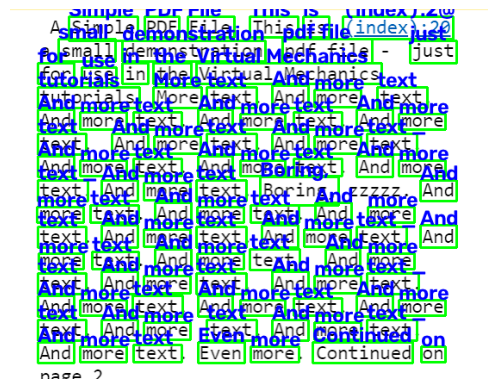

Using CPU. Note: This module is much faster with a GPU.



--- Final Extracted Text ---
Simple PDF File This is (index):2@ small demonstration pdf file just for use in the Virtual Mechanics tutorials More text And more text And more text And more text And more text And more text And more text _ And more text And more text And more text _ And more text Boring, And more text And more text And more text And more text And more text _ And more text And more text And more text And more text And more text _ And more text And more text And more text And more text And more text _ And more text Even more Continued on

------------------ Processing: C:\Users\Safyan Ahmad\Desktop\text_recognition-main\image2.png -------------------


c:\Users\Safyan Ahmad\Desktop\text_recognition-main\.img\Lib\site-packages\torch\utils\data\dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Detected: This is the first line of | Confidence: 0.85
Detected: this text example. | Confidence: 0.67
Detected: This is the second line | Confidence: 0.93
Detected: of the same text; | Confidence: 0.61


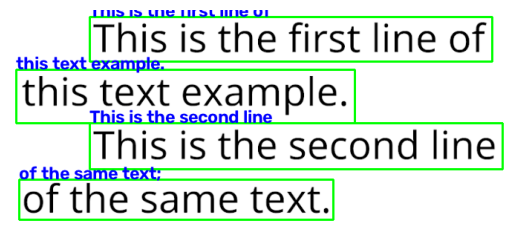

Using CPU. Note: This module is much faster with a GPU.



--- Final Extracted Text ---
This is the first line of this text example. This is the second line of the same text;

------------------ Processing: C:\Users\Safyan Ahmad\Desktop\text_recognition-main\image3.jpg -------------------


c:\Users\Safyan Ahmad\Desktop\text_recognition-main\.img\Lib\site-packages\torch\utils\data\dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Detected: It was the best of | Confidence: 0.98
Detected: times; it was the worst | Confidence: 0.58
Detected: of times, it was the age | Confidence: 0.88
Detected: of wisdom | Confidence: 0.70
Detected: ) | Confidence: 0.44
Detected: it was the | Confidence: 0.73
Detected: age of foolishness. | Confidence: 0.77


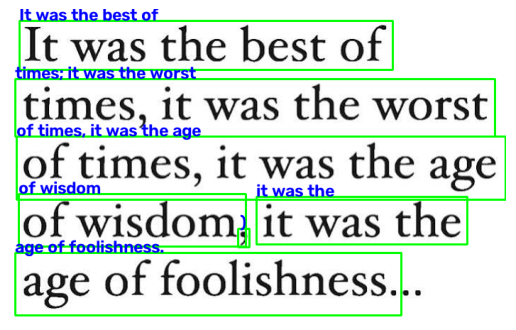


--- Final Extracted Text ---
It was the best of times; it was the worst of times, it was the age of wisdom ) it was the age of foolishness.


In [2]:
def recognize_text(image_path, confidence_threshold=0.4):
  reader = easyocr.Reader(['en'], gpu=False)

  results = reader.readtext(image_path)
  if not results:
    print('Koi text nahi mila.')
    return []

  valid_results = []
  extracted_texts = []

  for bbox, text, prob in results:
    if prob > confidence_threshold:
      valid_results.append((bbox, text, prob))
      extracted_texts.append(text)
      print(f'Detected: {text} | Confidence: {prob:.2f}')

  img = cv2.imread(image_path)
  for bbox, text, prob in valid_results:
    top_left = [int(i) for i in bbox[0]]
    bottom_right = [int(i) for i in bbox[2]]
    cv2.rectangle(img, top_left, bottom_right, (0, 255, 0), 2)
    cv2.putText(
        img, text, top_left, cv2.FONT_HERSHEY_SIMPLEX, 0.8, (255, 0, 0), 2
    )

  plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
  plt.axis('off')
  plt.show()

  return extracted_texts


image_paths = [
    r'C:\Users\Safyan Ahmad\Desktop\text_recognition-main\image1.png',
    r'C:\Users\Safyan Ahmad\Desktop\text_recognition-main\image2.png',
    r"C:\Users\Safyan Ahmad\Desktop\text_recognition-main\image3.jpg",
]

for path in image_paths:
  print(f'\n------------------ Processing: {path} -------------------')
  detected_words = recognize_text(path)

  print('\n--- Final Extracted Text ---')
  print(' '.join(detected_words))